# Data Analysis and Reporting with Structured Querying Language (SQL)

**🎯 Lesson Objectives**

**By the end of this lesson, you will be able to:**

- Understand the basics of SQL
- Construct SQL queries
- Learn to use sqlite3 and pandas libraries to interact with SQL databases

- **Work with SQL Columns**  
  - Remove duplicates with **DISTINCT**.  
  - Modify text using **TRIM** and **SUBSTR**.  
  - Measure text length with **LENGTH**.  
  
- **Transform and Convert Data**  
  - Join text with **CONCAT**.  
  - Change data types using **CAST**.  
  
- **Summarize and Group Data**  
  - Use **COUNT, SUM, AVG, MIN, MAX** for calculations.  
  - Organize data with **GROUP BY** and **HAVING**.  
  
- **Use Conditional Logic**  
  - Apply **CASE** statements for conditional data changes.  
  
- **Write Efficient SQL Queries**  
  - Use **ORDER BY, WHERE, and LIMIT** for better results.  


**🎯What we will cover:**

**Column operations**
- Explore DISTINCT, TRIM, SUBSTR, LENGTH, CONCAT, CAST
- AGGREGATE FUNCTIONS
- GROUP BY
- HAVING
- CASE STATEMENT
- General SQL query structure




---

## ☑️ Setting up the database connection

First, import pandas and sqlite3 libraries and create the connection to the `shop_db.db` database, located in the `data` folder:

In [1]:
import pandas as pd
import sqlite3
conn = sqlite3.connect('data/shop_db.db')

## ☑️ Shop database table structure (schema)
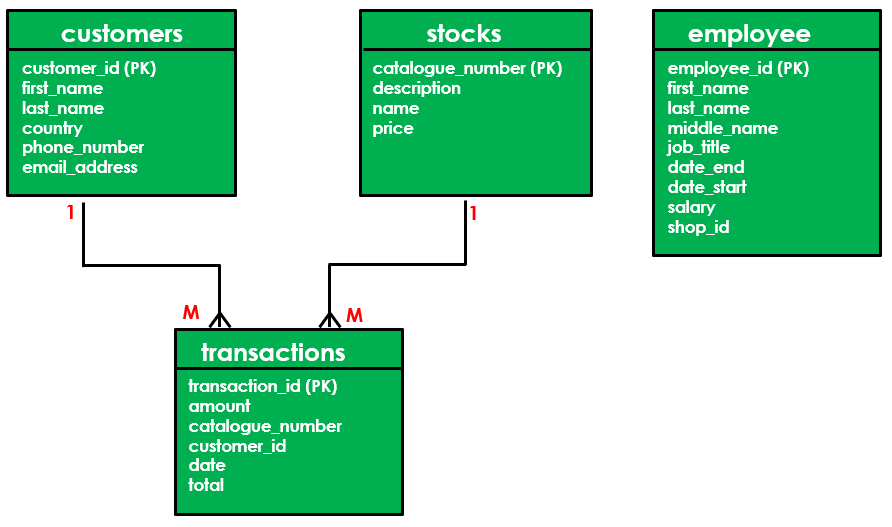

The customers table tracks all customer information, the stocks table tracks all product information, the transaction table tracks all transactions that had taken place and the employee table tracks information related to company employees. 

As illustrated above customer-transactions and stocks-transactions tables are having one-to-many relationships. Also please note the employee table is not connected to any other table.

In [2]:
query = """
SELECT name 
FROM sqlite_master 
WHERE type = 'table';
"""
df = pd.read_sql_query(query, conn)
df

,name
0,customers
1,stocks
2,transactions
3,employees


## **🔄 Recap: Key Elements from last session**  

Before learning **Column Operations in SQL**, it is important to understand some fundamental concepts. Below is an overview of key topics to grasp from our previous session.

**Question 1**

What is the primary advantage of using SQL over Pandas when handling large datasets?  

- **A)** SQL runs on the **client**, whereas Pandas runs on a **server**  
- **B)** Pandas supports **distributed computing**, while SQL does not  
- **C)** SQL can handle **larger datasets** efficiently since it runs on a **server**  
- **D)** SQL is faster than Pandas for **all** types of data manipulation  

In [3]:
#put your answer below



**Question 2**

Which of the following SQL queries follows best practices for readability and maintainability?  

```sql
A)  SELECT first_name,last_name,email_address FROM customers WHERE country='UK';

B)  SELECT first_name, last_name, email_address
    FROM customers
    WHERE country = 'UK';

C)  select first_name last_name email_address 
    from customers 
    where country='UK';

D)  SELECT first_name, last_name, email_address, WHERE country = 'UK';
```

In [4]:
#put your answer below



**Question 3**

Write an SQL query that retrieves all columns from the **transactions** table where the **amount** is greater than **500**, sorted in **descending order**.  

In [5]:
#Write your SQL query here

#query = ...
#df = pd.read_sql_query(query, conn)
#df

**Question 4**

Write an SQL query that retrieves **first_name**, **last_name**, and **email_address** from the **customers** table where the **email_address** ends with `.com`.  

In [6]:
#Write your SQL query here

#query = ...
#df = pd.read_sql_query(query, conn)
#df

---




# 🚀 Working with Column Operations

So far we've mainly talked about extracting row-based information from tables. Now we're going to discuss column-based operations. 

This is mostly going to be a list of functions: don't worry you're not supposed to memorise them all! Feel free to come back to this as much as you need to, the key thing is that you have an idea that these sorts of things exist.

In [7]:
query = """
SELECT *
FROM customers;
"""

df = pd.read_sql_query(query, conn)
df

,customer_id,first_name,last_name,country,phone_number,email_address
0,1,Rupert,Ascot,UK,00123456789,rupert@ascot.co.uk
1,2,Nargess,Newton-Jones,None,None,isaac@nj.com
2,3,Arthur,King,None,None,None
3,4,Alice,Lindell,DE,49492180185611,None
4,5,Alicia,Gaius,UK,None,None
5,6,Emma,Rock,FR,None,None


## ☑️ DISTINCT

Returns only distinct values and eliminates duplicates 
```SQL
SELECT DISTINCT(column) FROM table;
```


In [8]:
query = """
SELECT DISTINCT(country)
FROM customers;
"""

df = pd.read_sql_query(query, conn)
df

,country
0,UK
1,None
2,DE
3,FR


In our example if we just returned the country column it might be hard to read off a list of the countries our customers come from. Instead we can get the list of unique countries using the DISTINCT function in the SELECT part of the query. 

This is also sometimes helpful for debugging! When for example we have two slightly different spellings of the same item, it's easy to spot using the DISTINCT function. 

#### 💡 Knowledge Check 1  

What is the purpose of the `DISTINCT` function in SQL?  

- **A)** It counts the number of rows in a table  
- **B)** It returns only unique values from a column, removing duplicates  
- **C)** It sorts the values in a column in ascending order  
- **D)** It replaces NULL values in a column with a default value  

In [9]:
#put your answer below



## ☑️ TRIM

Removes a specified prefix or suffix from a string (default: whitespace).

```SQL
SELECT TRIM(column) FROM table;
```

In [10]:
#Example_1

query = """
SELECT TRIM(country)
FROM customers;
"""

df = pd.read_sql_query(query, conn)
df

,TRIM(country)
0,UK
1,None
2,None
3,DE
4,UK
5,FR


Another column-wise operation is TRIM - this is particularly useful for string-processing when for example we want to eliminate the whitespace from strings.

Indeed, this is the default behaviour (i.e. if we don't specify what to trim, the TRIM function will default to removing any whitespace from each row in the specified column). The most common example of this is if we want to remove unwanted spaces from strings like email addresses, or phone numbers.

In [11]:
#Example_2

query = """
SELECT first_name, TRIM(first_name, 'A')
FROM customers;
"""

df = pd.read_sql_query(query, conn)
df

,first_name,"TRIM(first_name, 'A')"
0,Rupert,Rupert
1,Nargess,Nargess
2,Arthur,rthur
3,Alice,lice
4,Alicia,licia
5,Emma,Emma


A less subtle example is, for example, removing the character "A" from all of the strings in the column "first_name".

This is obviously not the most practical example, but you can imagine that maybe we have some special characters in there that we want to get rid of.

## ☑️ SUBSTR

SUBSTR function is a slight extension of TRIM: it lets us actually index the strings to extract some subset of the characters. 

It takes three parameters: the column to operate on, the starting position X and the length of the substring Y (i.e. the number of characters to take starting from position X).

Given

```SQL
SELECT SUBSTR(column, X, Y) FROM table_name;
```

extracts a substring of length Y, starting at character X. 

Example:


```SQL
SELECT SUBSTR(first_name, 3, 1) FROM customers;
```

In [12]:
query = """
SELECT first_name, SUBSTR(first_name, 3, 1) AS name_letter
FROM customers;
"""

df = pd.read_sql_query(query, conn)
df

,first_name,name_letter
0,Rupert,p
1,Nargess,r
2,Arthur,t
3,Alice,i
4,Alicia,i
5,Emma,m


In this example, we take the column "first_name" and get 1 character starting from position 3. So for example the name "Rupert" becomes "p", "Emma" becomes "m". 

#### 💡 Knowledge Check 2

Write an SQL query to find how many `unique customer IDs` exist in the transactions table where the date **column is not null**.

*How many are there?*

In [13]:
#Write your SQL query here

#query = ...
#df = pd.read_sql_query(query, conn)
#df

## ☑️ LENGTH

Returns the length of a string.

```SQL
SELECT LENGTH(column) FROM table;
```

In [14]:
query = """
SELECT first_name, LENGTH(first_name) AS name_length
FROM customers;
"""

df = pd.read_sql_query(query, conn)
df

,first_name,name_length
0,Rupert,6
1,Nargess,7
2,Arthur,6
3,Alice,5
4,Alicia,6
5,Emma,4


Here's an example of how to use the LENGTH function. Suppose we have a table called "customers" with a column called "first_name" that contains the names of customers. We want to find the length of each customer's first name.

## ☑️ CONCAT

The CONCAT function is used to concatenate (join) two or more strings together. 

Please note in some SQL clients, there is a CONCAT function however in SQLite this is an operator: bar bar (||).

```SQL
SELECT column1 || column2 FROM table;
```

In [15]:
query = """
SELECT first_name || ' ' || last_name AS full_name
FROM customers;
"""

df = pd.read_sql_query(query, conn)
df

,full_name
0,Rupert Ascot
1,Nargess Newton-Jones
2,Arthur King
3,Alice Lindell
4,Alicia Gaius
5,Emma Rock


CONCAT is also an operation you might have come across in Python too. In the above example, we are concatenating the first and last name of each of our customers.

## ☑️ CAST

The CAST function is used to convert a value from one data type to another. It takes two arguments: the value to be converted and the target data type.

Syntax:
```SQL
SELECT CAST(column AS data_type) FROM table;
```

In [16]:
query = """
SELECT phone_number, CAST(phone_number AS INT)
FROM customers;
"""

df = pd.read_sql_query(query, conn)
df

,phone_number,CAST(phone_number AS INT)
0,00123456789,1.234568e+08
1,None,NaN
2,None,NaN
3,49492180185611,4.949218e+13
4,None,NaN
5,None,NaN


A common example for this is when we end up reading inputs from a file and we have numbers as strings: we might want to CAST them into a number format.
 
In this example we convert the column phone_number from STRINGs into integers - again not a particularly practical example but it's a good illustrator of how this works.

## ☑️ AGGREGATE FUNCTIONS

SQL aggregate functions are used to perform calculations on sets of values and return a single value as the result (summary statistics).

They are commonly used with the SELECT statement and GROUP BY clause to aggregate data in a meaningful way.

```SQL
SELECT COUNT(column) FROM table;
SELECT SUM(column) FROM table;
SELECT AVG(column) FROM table;
SELECT MIN(column) FROM table;
SELECT MAX(column) FROM table;
```

In [17]:
query = """
SELECT SUM(total), MAX(total), MIN(total)
FROM transactions;
"""

df = pd.read_sql_query(query, conn)
df

,SUM(total),MAX(total),MIN(total)
0,162.7,120.0,5.1


In the above example, we're applying SUM(), MAX() and MIN() over the whole column "total".

These operations are particularly interesting when grouping data as we will see shortly.

#### 💡 Knowledge Check 3

What is the primary purpose of the `CAST` function in SQL?  

- **A)** To remove `NULL` values from a column  
- **B)** To concatenate two string columns  
- **C)** To **convert** a value from **one data type to another**  
- **D)** To filter out **duplicate rows**  

In [18]:
#put your answer below



## ☑️ GROUP BY

SQL allows you to group data using the GROUP BY keyword. 

The GROUP BY keyword groups data based on one or more columns in a table and produces summary statistics for that group.

In [19]:
query = """
SELECT customer_id, SUM(total) AS total_spent_per_customer
FROM transactions
GROUP BY customer_id
ORDER BY total_spent_per_customer DESC;
"""

df = pd.read_sql_query(query, conn)
df

,customer_id,total_spent_per_customer
0,2,125.1
1,4,30.6
2,3,7.0


In the transactions table, we might have multiple transactions per customer.

- In this example, we GROUP BY customer_id, so that the transactions are split into several groups: one per customer. 

- Then we apply SUM() function, to calculate the total spent per group (and therefore per customer).

- We also use an "ORDER BY" to sort the rows by their total spend. 

- We can see the result in the table: there is now one row per customer ID, with the id mapping to total spend.

*Note that any column in the SELECT statement that is not included in the GROUP BY must be aggregated using a function such as SUM, AVG, MAX, MIN, etc. This is because each row in the result set corresponds to a unique combination of the columns specified in the GROUP BY.*

## ☑️ HAVING

The HAVING keyword is used in SQL in combination with the GROUP BY to filter aggregated results.

In [20]:
query = """
SELECT customer_id, SUM(total) AS total_spent_per_customer
FROM transactions
GROUP BY customer_id
HAVING total_spent_per_customer > 10
ORDER BY total_spent_per_customer DESC;
"""

df = pd.read_sql_query(query, conn)
df

,customer_id,total_spent_per_customer
0,2,125.1
1,4,30.6


**Important**: WHERE is used to filter rows, HAVING is used to filtering aggregated results

In the above example, we are calculating SUM per customer, but this time filter the results of sum of total spend, greater than 10. 

#### 💡 Knowledge Check 4

Write an SQL query to calculate the total amount spent by each customer in the `transactions` table.

- Use the **GROUP BY** clause to group transactions by `customer_id`.  
- Apply the **SUM()** function to calculate the total spend per customer.  
- Sort the results in descending order of total spend.  


In [21]:
#Write your SQL query here

#query = ...
#df = pd.read_sql_query(query, conn)
#df

## ☑️ CASE STATEMENT

The CASE statement in SQL is used to check conditions and perform tasks on each row while selecting data (like an if-else statement). It can be used in a SELECT statement to create a calculated column.

```SQL
SELECT column1, column2, column3,
CASE
    WHEN condition1 THEN result1
    WHEN condition2 THEN result2
    ...
    ...
    WHEN conditionN THEN resultN
    ELSE result
END AS some_alias
FROM table;
```

The CASE statement goes through conditions and returns a result. 

- "CASE": This keyword marks the start of the CASE statement.

- "WHEN": This keyword is used to specify a condition. So, once a condition is true, "THEN" keyword will return a result. 

- "ELSE": This specifies the default result that should be returned if none of the "WHEN" conditions are true.

- "END": This keyword marks the end of the SQL CASE statement. This creates a new column with the alias "some_alias".

In [22]:
query = """
SELECT first_name, phone_number, email_address,
CASE
    WHEN phone_number IS NULL AND email_address IS NULL THEN 'No contact details'
    WHEN phone_number IS NULL THEN email_address
    ELSE phone_number
END AS contact_details
FROM customers;
"""

df = pd.read_sql_query(query, conn)
df

,first_name,phone_number,email_address,contact_details
0,Rupert,00123456789,rupert@ascot.co.uk,00123456789
1,Nargess,None,isaac@nj.com,isaac@nj.com
2,Arthur,None,None,No contact details
3,Alice,49492180185611,None,49492180185611
4,Alicia,None,None,No contact details
5,Emma,None,None,No contact details


Take a minute to read through this query.

We're creating a column called "contact_details": first we check if both the phone_number and email_address are NULL, then we return the string 'No contact details'.

If this isn't true then it means that either of phone number or email address is there. Next, we check if phone_number is NULL: if it is then email_address must have a value, so we return it.

Finally, if it's not true that phone_number is null, this must mean that it has a value, so we return it.

The result is the table you see, with our new column contact_details. Where users had neither email nor phone number, we have a string 'no contact details'. Where there is only an email address, we have that. Where there is just a phone number or both a phone number and an email address: we return the phone number. 

## ☑️ General SQL query structure

```SQL
SELECT <column_list>
FROM <table_name>
WHERE <filter_condition>
GROUP BY <grouping>
HAVING <aggregate_filter_condition>
ORDER BY <column_list> [ASC|DESC]
LIMIT <number_of_rows>;
```
Now that we've seen a few queries we can start to think about the general structure of SQL queries. This sort of template might be a useful reference point for the exercises, but will start to feel natural soon enough! 

We always specify the columns we want first with SELECT - and any column-wise operations go here too. 

Next, we specify the table we are collecting data from, followed by the row-filtering options: WHERE, GROUP BY, HAVING. 

#### 💡 Knowledge Check 5

What is the primary purpose of a `CASE` statement in SQL?  

- **A)** To define new SQL tables dynamically  
- **B)** To **perform conditional logic** within a `SELECT` statement  
- **C)** To create indexes for faster queries  
- **D)** To join multiple tables  

In [23]:
#put your answer below



### **🔑 Summary / Key Takeaways**
By completing this lesson, you should now be able to:
- ✅ Use SQL functions like **DISTINCT, TRIM, SUBSTR, LENGTH, CONCAT, and CAST**.  
- ✅ Apply **aggregate functions** for data summarization.  
- ✅ Group data using **GROUP BY** and filter with **HAVING**.  
- ✅ Implement conditional logic using the **CASE statement**.  
- ✅ Understand the **general SQL query structure**.  

### **📝 Next Steps:**  

- **Complete the practical lab work**: Open and work through the following workbook:`intro-sql-part2-workbook.ipynb`. 